Esta arquivo mostra a Análise Exploratória de Dados

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Conecta ao banco de dados SQLite
conn = sqlite3.connect("biblioteca.db")

#Carrega os selects com as infos a serem utilizadas nos gráficos para o DataFrame do Pandas
df_livros = pd.read_sql_query("SELECT * FROM livros", conn)
df_autores = pd.read_sql_query("SELECT * FROM autores", conn)
df_categorias = pd.read_sql_query("SELECT * FROM categorias", conn)
df_clientes = pd.read_sql_query("SELECT * FROM clientes", conn)
df_downloads = pd.read_sql_query("SELECT * FROM downloads", conn)
df_notas = pd.read_sql_query("SELECT nota FROM downloads", conn)

In [10]:
#Estatísticas básicas
print("Estatísticas básicas - Composição do Dataset\n")
print("Total de categorias:", df_categorias.shape[0])
print("Total de livros:", df_livros.shape[0])
print("Total de autores:", df_autores.shape[0])
print("Total de clientes:", df_clientes.shape[0])
print("Total de downloads:", df_downloads.shape[0])
print("Média de Downloads por Cliente:", round(df_downloads.shape[0] / df_clientes.shape[0]))

Estatísticas básicas - Composição do Dataset

Total de categorias: 13
Total de livros: 156
Total de autores: 261
Total de clientes: 2400
Total de downloads: 7246
Média de Downloads por Cliente: 3


In [23]:
#Top 10 livros mais baixados 
livros_mais_baixados = pd.read_sql_query("""
    SELECT l.title AS Livros, COUNT(d.livro_id) AS Downloads
    FROM downloads d
    JOIN livros l ON d.livro_id = l.id
    GROUP BY d.livro_id
    ORDER BY Downloads DESC
    LIMIT 10
""", conn)

#Torna as primeiras letras maiúsculas
livros_mais_baixados['Livros'] = livros_mais_baixados['Livros'].str.capitalize()

#Alinha os cabeçalhos á esquerda
styles = [
    {'selector': 'th', 'props': [('text-align', 'left')]},
    {'selector': 'td', 'props': [('text-align', 'left')]}
]

#Estiliza o gráfico
livros_mais_baixados_styled = livros_mais_baixados.style.set_table_styles(styles).background_gradient(cmap="Blues", subset=["Downloads"])
livros_mais_baixados_styled

,Livros,Downloads
0,The hound of the baskervilles,64
1,Meret oppenheim,61
2,"The art of money getting, or, golden rules for money getting",60
3,Heinemann mathematics,59
4,Julius caesar,59
5,Captains courageous,59
6,Through the looking-glass,59
7,History of the peloponnesian war,58
8,Sane sex life and sane sex living,58
9,The wonderful wizard of oz,58


In [12]:
#Top 10 livros melhor avaliados
notas_livros = pd.read_sql_query("""
    SELECT l.title AS Livros, c.name AS Categoria, AVG(d.nota) AS Estrelas
    FROM downloads d
    JOIN livros AS l ON d.livro_id = l.id
    JOIN categorias AS c ON l.categoria_id = c.id
    GROUP BY d.livro_id, c.name
    ORDER BY Estrelas DESC
    LIMIT 10
""", conn)

#Torna as primeiras letras maiúsculas
notas_livros['Livros'] = notas_livros['Livros'].str.capitalize()
notas_livros['Categoria'] = notas_livros['Categoria'].str.capitalize()

#Reduz os valores da coluna "Estrelas" para duas casas decimais
notas_livros['Estrelas'] = notas_livros['Estrelas'].round(2)

#Alinha os cabeçalhos á esquerda
styles = [
    {'selector': 'th', 'props': [('text-align', 'left')]},
    {'selector': 'td', 'props': [('text-align', 'left')]}
]

#Estiliza o gráfico e formata a coluna "Estrelas" para duas casas decimais
notas_livros_styled = notas_livros.style.set_table_styles(styles).background_gradient(cmap="Blues", subset=["Estrelas"]).format({"Estrelas": "{:.2f}"})

#Exibe a tabela
notas_livros_styled

,Livros,Categoria,Estrelas
0,Acres of diamonds,Business,3.58
1,The jungle book,Animals,3.49
2,Alice's adventures in wonderland,Animals,3.47
3,Principles of anatomy and physiology,Textbooks,3.45
4,Treasure island,Juvenile fiction,3.41
5,What is mathematics?,Sciencemathematics,3.40
6,Microbiology,Sciencemathematics,3.39
7,Treasure island,History,3.33
8,Little women,Juvenile fiction,3.32
9,A christmas carol,Animals,3.31


In [19]:
#TOP 10 autores mais populares (baseado em downloads)
df_livros_autores = pd.read_sql_query("""
    SELECT a.name AS Autor, COUNT(d.id) AS Downloads
    FROM livro_autor la
    JOIN autores a ON la.autor_id = a.id
    JOIN downloads d ON la.livro_id = d.livro_id
    GROUP BY la.autor_id
    ORDER BY Downloads DESC
    LIMIT 10
""", conn)

# Torna as primeiras letras maiúsculas
df_livros_autores['Autor'] = df_livros_autores['Autor'].str.capitalize()

# Alinha os cabeçalhos à esquerda
styles = [
    {'selector': 'th', 'props': [('text-align', 'left')]},
    {'selector': 'td', 'props': [('text-align', 'left')]}
]

# Estiliza e exibe a tabela
df_livros_autores_styled = df_livros_autores.style.set_table_styles(styles).background_gradient(cmap="Blues", subset=["Downloads"])
df_livros_autores_styled


,Autor,Downloads
0,Charles dickens,478
1,William shakespeare,397
2,Jane austen,314
3,Lewis carroll,289
4,Rudyard kipling,194
5,Mark twain,184
6,James zimmerhoff,149
7,Julius seybt,146
8,Julius julius seybt,146
9,Miguel muñoz,146


In [27]:
#Top 10 livros com pior avaliação 
notas_livros = pd.read_sql_query("""
    SELECT l.title AS Livros, 
           AVG(d.nota) AS Estrelas
    FROM downloads d
    JOIN livros l ON d.livro_id = l.id
    JOIN livro_autor la ON l.id = la.livro_id
    GROUP BY d.livro_id
    ORDER BY Estrelas ASC
    LIMIT 10
""", conn)

#Torna as primeiras letras maiúsculas para o nome dos livros
notas_livros['Livros'] = notas_livros['Livros'].str.capitalize()

#Alinha os cabeçalhos à esquerda
styles = [
    {'selector': 'th', 'props': [('text-align', 'left')]},
    {'selector': 'td', 'props': [('text-align', 'left')]}
]

#Formata a quantidade de caracteres pra 40 no máximo para os nomes dos livros
notas_livros['Livros'] = notas_livros['Livros'].str[:40]

#Estiliza
notas_livros_styled = notas_livros.style.set_table_styles(styles).background_gradient(cmap="Reds", subset=["Estrelas"]).format({"Estrelas": "{:.2f}"})

#Exibe a tabela
notas_livros_styled

,Livros,Estrelas
0,The pleasures of imagination,2.51
1,Implementation of the helsinki accords,2.53
2,Domestic medicine,2.54
3,Wonder,2.55
4,Chto takoe iskusstvo? / what is art?,2.55
5,The history of england from the accessio,2.55
6,Bible,2.56
7,Carmina,2.60
8,Μένων,2.64
9,Piazze d'italia,2.64


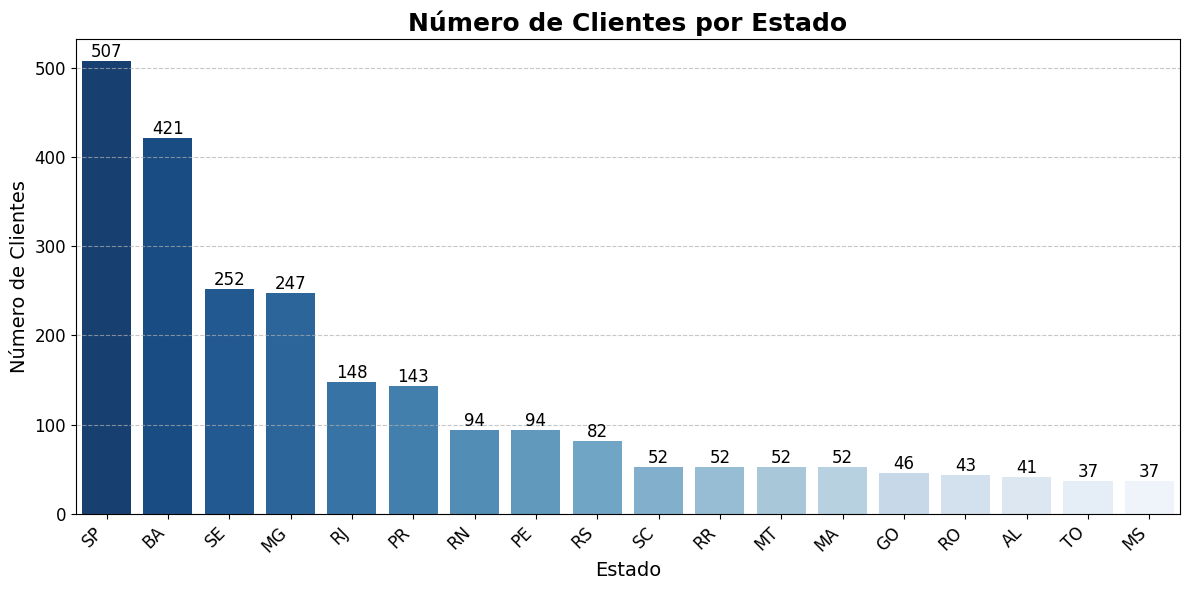

In [15]:
# Seleciona os dados de quantidade de clientes por estado
query_clientes = """
    SELECT estado, COUNT(id) AS num_clientes
    FROM clientes
    GROUP BY estado
    ORDER BY num_clientes DESC
"""
# Carrega os dados do SQLite
clientes_por_estado = pd.read_sql_query(query_clientes, conn)

# Cria o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x="estado", y="num_clientes", data=clientes_por_estado, hue="estado", palette="Blues_r", dodge=False)
plt.legend([],[], frameon=False)  # Remove a legenda

# Adiciona os números dentro das barras
for index, row in clientes_por_estado.iterrows():
    plt.text(index, row.num_clientes, row.num_clientes, color='black', ha="center", va="bottom", fontsize=12)

# Estiliza o gráfico
plt.title('Número de Clientes por Estado', fontsize=18, fontweight='bold')
plt.xlabel('Estado', fontsize=14)
plt.ylabel('Número de Clientes', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibe o gráfico
plt.show()



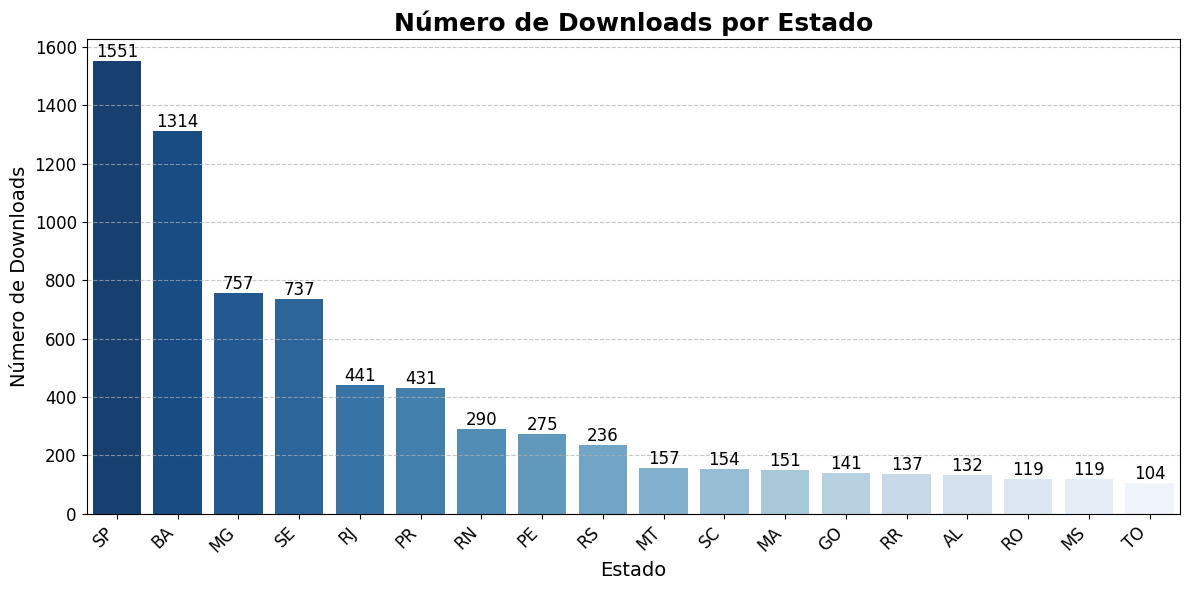

In [16]:
# Seleciona os dados de cada estado e cruza com as informações das tabelas downloads
query = """
    SELECT estado, COUNT(d.id) AS num_downloads
    FROM downloads d
    JOIN clientes c ON d.cliente_id = c.id
    GROUP BY estado
    ORDER BY num_downloads DESC
"""
# Carrega os dados do SQLite
downloads_por_estado = pd.read_sql_query(query, conn)

# Cria o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x="estado", y="num_downloads", data=downloads_por_estado, hue="estado", palette="Blues_r", dodge=False)
plt.legend([],[], frameon=False)  # Remove a legenda

# Adiciona os números dentro das barras
for index, row in downloads_por_estado.iterrows():
    plt.text(index, row.num_downloads, row.num_downloads, color='black', ha="center", va="bottom", fontsize=12)

# Estiliza o gráfico
plt.title('Número de Downloads por Estado', fontsize=18, fontweight='bold')
plt.xlabel('Estado', fontsize=14)
plt.ylabel('Número de Downloads', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibe o gráfico
plt.show()